In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv("../data/processed/subway_trains_delayed_cleaned.csv")
df['month_date'] = pd.to_datetime(df['month_date'])

df.head()


,Day Type Name,division,delays,line,Month Name,reporting_category,Year,Quarter,month_date
0,Weekday,A DIVISION,1,GS,April,Crew Availability,2023,Qtr 2,2023-04-01
1,Weekday,A DIVISION,1,GS,August,Crew Availability,2020,Qtr 3,2020-08-01
2,Weekday,A DIVISION,1,GS,December,Crew Availability,2022,Qtr 4,2022-12-01
3,Weekday,A DIVISION,1,GS,February,Crew Availability,2023,Qtr 1,2023-02-01
4,Weekday,A DIVISION,1,GS,March,Crew Availability,2024,Qtr 1,2024-03-01


In [ ]:
df['delays'].describe()



count    17171.000000
mean       147.335042
std        178.235717
min          1.000000
25%         26.000000
50%         81.000000
75%        201.000000
max       1836.000000
Name: delays, dtype: float64

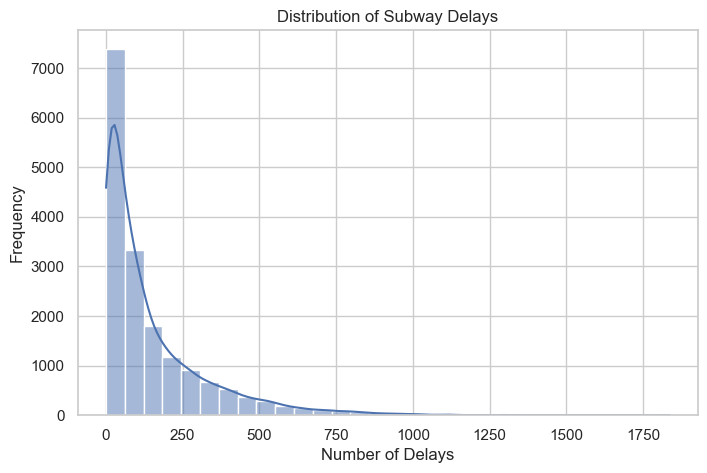

In [3]:
plt.figure(figsize=(8,5))
sns.histplot(df['delays'], bins=30, kde=True)
plt.title("Distribution of Subway Delays")
plt.xlabel("Number of Delays")
plt.ylabel("Frequency")
plt.show()


### Distribution Insight

The distribution of subway delays is highly right-skewed. Most observations show relatively low delay counts, while a small number of periods experience extreme delays. This suggests that while delays are common, severe disruption events are infrequent but potentially high impact.


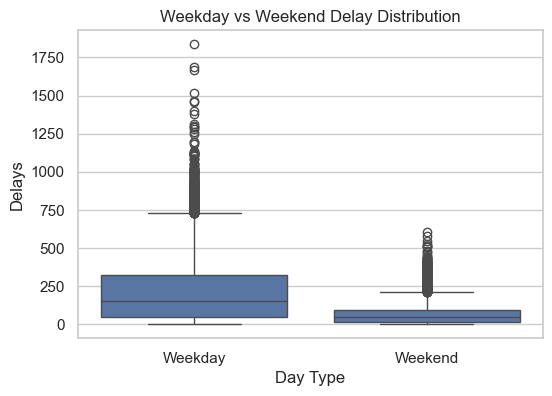

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Day Type Name', y='delays', data=df)
plt.title("Weekday vs Weekend Delay Distribution")
plt.xlabel("Day Type")
plt.ylabel("Delays")
plt.show()


### Weekday vs Weekend Insight

Weekday delays show a higher median and substantially greater variability compared to weekends. The presence of numerous high-value outliers during weekdays indicates that severe delay events are more frequent during regular workdays, likely due to higher ridership and operational complexity.

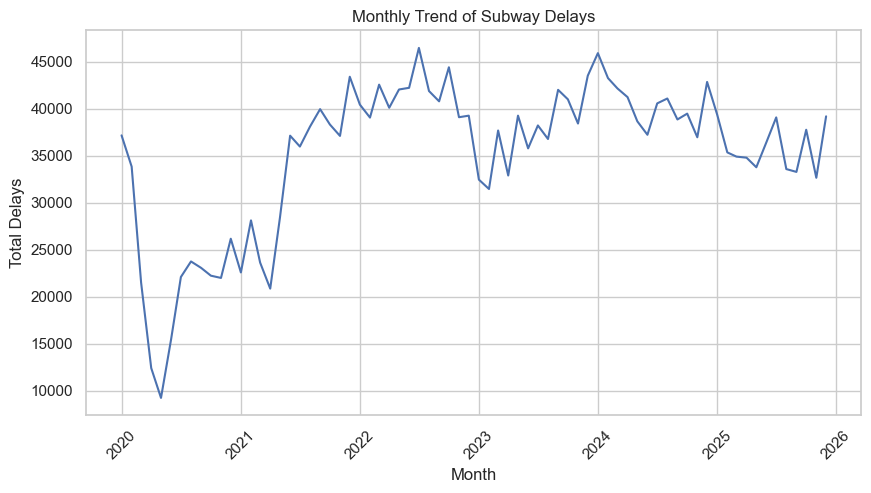

In [7]:
monthly_delays = (
    df.groupby('month_date')['delays']
      .sum()
      .reset_index()
      .sort_values('month_date')
)

plt.figure(figsize=(10,5))
sns.lineplot(x='month_date', y='delays', data=monthly_delays)
plt.title("Monthly Trend of Subway Delays")
plt.xlabel("Month")
plt.ylabel("Total Delays")
plt.xticks(rotation=45)
plt.show()


### Monthly Trend Insight

A sharp decline in total delays is observed in early 2020, likely reflecting reduced subway operations during the COVID-19 pandemic. Following this period, delays steadily increased through 2021 and 2022 as ridership and operational activity recovered. From 2022 onward, total monthly delays stabilized within a higher but fluctuating range, indicating a return to normal operational conditions with recurring variability.

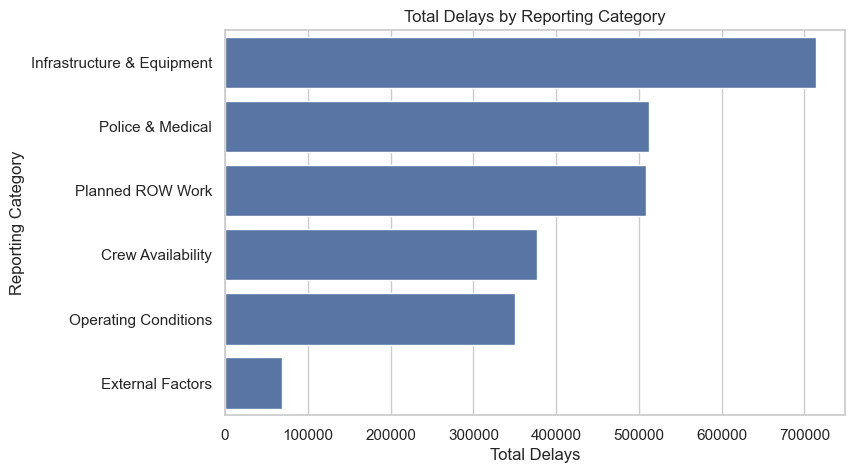

In [ ]:
category_delays = (
    df.groupby('reporting_category')['delays']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(8,5))
sns.barplot(x='delays', y='reporting_category', data=category_delays)
plt.title("Total Delays by Reporting Category")
plt.xlabel("Total Delays")
plt.ylabel("Reporting Category")
plt.show()



### Delay Drivers Insight

Infrastructure and equipment issues represent the largest source of subway delays, significantly exceeding all other categories. Police and medical incidents, as well as planned right-of-way (ROW) work, also contribute substantially. In contrast, external factors account for a relatively small portion of total delays.

This suggests that internal operational and infrastructure improvements could have the greatest impact on reducing overall delays.
